# 🚀 Step 6 — Advanced Regression Models: Improving R² & Variable Significance

> **Goal:** Push R² well beyond the baseline OLS (≈ 0.41) by introducing
> more sophisticated regression strategies — and rigorously test **which predictors
> are statistically significant** in each model.

---

### Models added in this notebook

| Model | Key idea | Expected R² gain |
|---|---|---|
| ElasticNet | Combines Ridge + LASSO penalties | Moderate |
| Polynomial OLS (degree 2) | Adds quadratic & cross terms | Moderate |
| OLS + Country Fixed Effects | Controls for all time-invariant country traits | **Large** |
| OLS + Year Fixed Effects | Controls for global shocks per year | Small |
| OLS + Country + Year FE | Two-way fixed effects | **Largest** |
| Ridge on Full Fixed-Effects | Regularises the FE model | Stable |

Each model comes with a **significance table** (t-stat, p-value, 95 % CI) and
a visual showing how many predictors survive the 5 % threshold.

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, ElasticNetCV, Ridge
)
from sklearn.preprocessing import (
    StandardScaler, PolynomialFeatures
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Presentation theme ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#2e3347',
    'axes.labelcolor'   : '#c8ccd8',
    'axes.titlecolor'   : '#e8eaf0',
    'xtick.color'       : '#8890a8',
    'ytick.color'       : '#8890a8',
    'grid.color'        : '#2e3347',
    'grid.linewidth'    : 0.6,
    'text.color'        : '#e8eaf0',
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'figure.dpi'        : 130,
})

ACCENT   = '#4fc3f7'
ACCENT2  = '#ff6b6b'
ACCENT3  = '#a5d6a7'
ACCENT4  = '#ffb74d'
ACCENT5  = '#ce93d8'
SIG_CLR  = '#a5d6a7'   # green  = significant
NSIG_CLR = '#ff6b6b'   # red    = not significant
GRAD     = ['#4fc3f7','#7986cb','#ff6b6b','#ffb74d',
             '#a5d6a7','#f48fb1','#80cbc4','#ce93d8','#ef9a9a']

SEED = 42
np.random.seed(SEED)

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(r"df_features.csv")

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
TARGET_LOG = 'log_attacks'

sub = df[FEATURES + [TARGET_LOG, 'attacks', 'country', 'year']].dropna().reset_index(drop=True)
X_raw = sub[FEATURES].values
y     = sub[TARGET_LOG].values

imp = SimpleImputer(strategy='median').fit(X_raw)
scl = StandardScaler().fit(imp.transform(X_raw))
X_s = scl.transform(imp.transform(X_raw))

kf  = KFold(n_splits=5, shuffle=True, random_state=SEED)
n, p = X_s.shape

print(f'Dataset: {n:,} observations × {p} core features')
print(f'Countries: {sub["country"].nunique()}  |  Years: {sub["year"].min()}–{sub["year"].max()}')

Dataset: 2,742 observations × 9 core features
Countries: 140  |  Years: 1996–2020


## 6.1 Helper: OLS significance table from scratch

We compute **t-statistics**, **p-values**, and **95 % confidence intervals** 
manually using the classic OLS formula:

$$SE(\hat{\beta}) = \sqrt{\hat{\sigma}^2 (X^T X)^{-1}_{jj}}, \quad t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

In [3]:
def ols_significance(X_fit, y_fit, feature_names, alpha=0.05):
    """
    Fit OLS and return a DataFrame with:
    coef, SE, t-stat, p-value, CI_lower, CI_upper, significant flag.
    Works on any X (including dummies), uses pseudo-inverse for stability.
    """
    n_obs, k = X_fit.shape
    # Add intercept
    X1    = np.column_stack([np.ones(n_obs), X_fit])
    names = ['intercept'] + list(feature_names)

    model  = LinearRegression(fit_intercept=False).fit(X1, y_fit)
    coefs  = model.coef_
    y_hat  = model.predict(X1)
    resid  = y_fit - y_hat
    df_res = n_obs - k - 1
    sigma2 = np.sum(resid**2) / df_res
    XtX_inv = np.linalg.pinv(X1.T @ X1)
    se     = np.sqrt(np.maximum(np.diag(XtX_inv) * sigma2, 0))

    t_stat = np.where(se > 0, coefs / se, 0.0)
    p_val  = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df_res))
    t_crit = stats.t.ppf(1 - alpha/2, df=df_res)
    ci_lo  = coefs - t_crit * se
    ci_hi  = coefs + t_crit * se
    r2_val = r2_score(y_fit, y_hat)

    return pd.DataFrame({
        'Feature'    : names,
        'Coef'       : np.round(coefs,  5),
        'SE'         : np.round(se,     5),
        't_stat'     : np.round(t_stat, 3),
        'p_value'    : np.round(p_val,  5),
        'CI_lower'   : np.round(ci_lo,  5),
        'CI_upper'   : np.round(ci_hi,  5),
        'Significant': p_val < alpha,
    }), r2_val


def cv_r2(X_fit, y_fit, model=None):
    if model is None:
        model = LinearRegression()
    return cross_val_score(model, X_fit, y_fit, cv=kf, scoring='r2').mean()


def sig_summary(sig_df, title):
    """Print significance counts, excluding intercept."""
    core = sig_df[sig_df['Feature'] != 'intercept']
    n_sig  = core['Significant'].sum()
    n_tot  = len(core)
    print(f'  [{title}]  Significant: {n_sig}/{n_tot}  '
          f'({n_sig/n_tot*100:.0f}%)')
    return n_sig, n_tot


print('Significance helper functions defined ✓')

Significance helper functions defined ✓


## 6.2 Baseline OLS — significance recap

We revisit the baseline to set the benchmark for both R² and variable significance.

  [OLS baseline]  Significant: 4/9  (44%)
  CV R² = 0.4102   In-sample R² = 0.4168


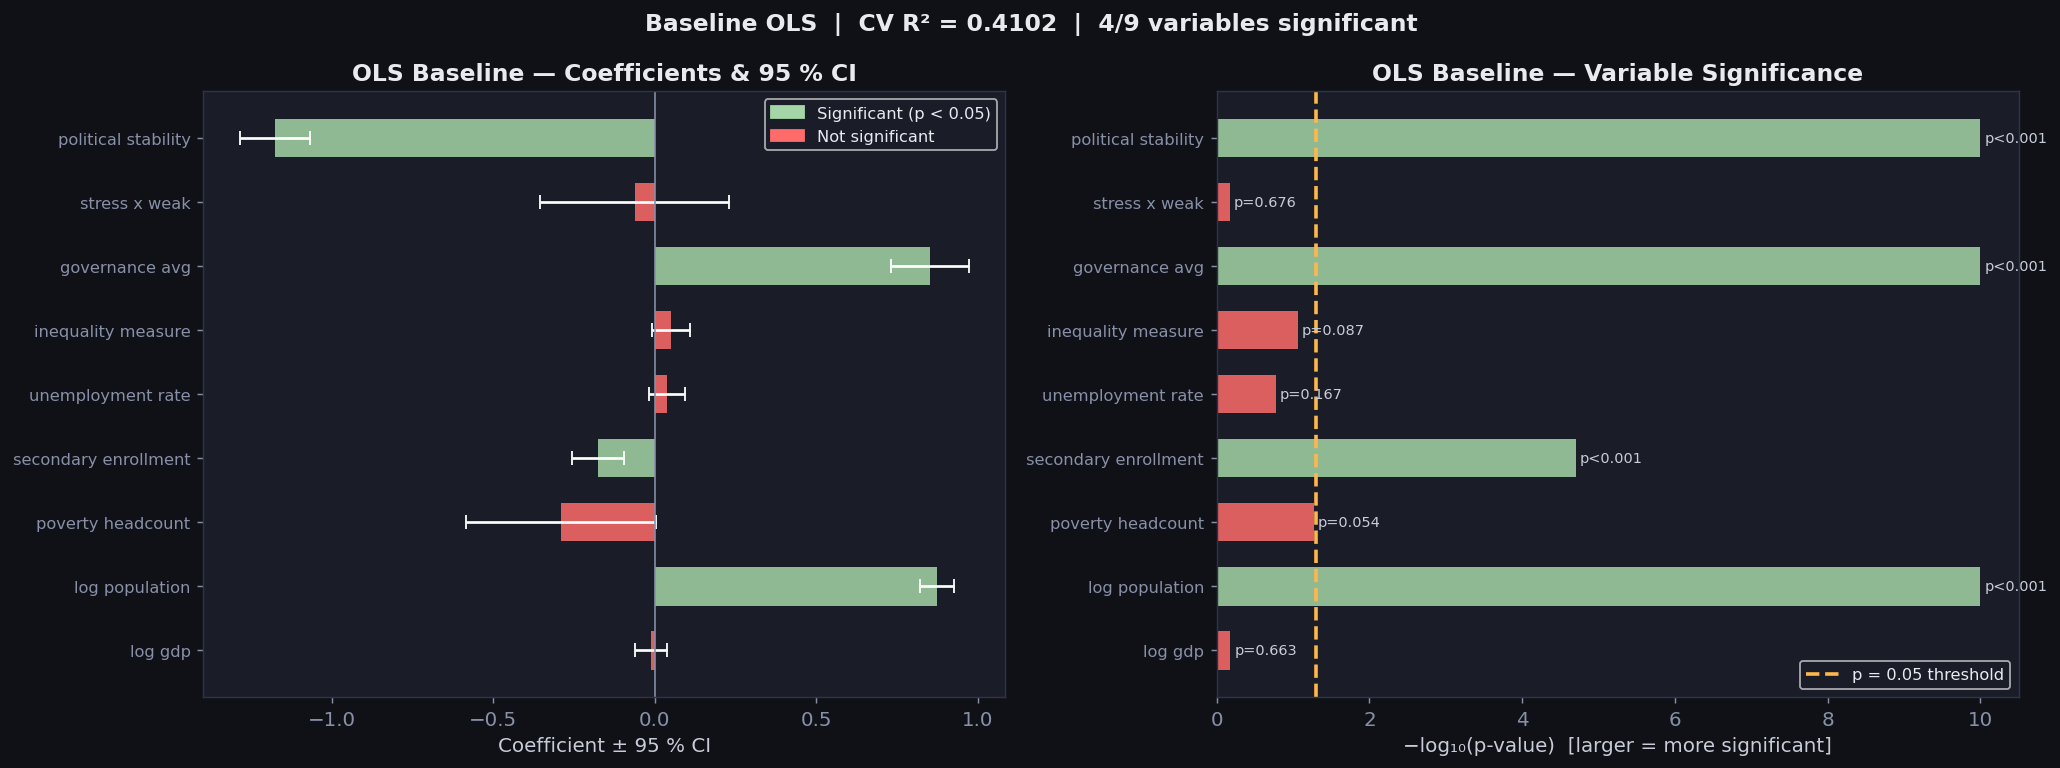

             Feature     Coef  t_stat  p_value  Significant
             log_gdp -0.01128  -0.436  0.66288        False
      log_population  0.87484  32.583  0.00000         True
   poverty_headcount -0.28911  -1.928  0.05398        False
secondary_enrollment -0.17556  -4.283  0.00002         True
   unemployment_rate  0.03849   1.384  0.16650        False
  inequality_measure  0.05127   1.715  0.08654        False
      governance_avg  0.85199  13.893  0.00000         True
       stress_x_weak -0.06240  -0.418  0.67575        False
 political_stability -1.17546 -21.030  0.00000         True


In [4]:
sig_ols, r2_ols_is = ols_significance(X_s, y, FEATURES)
cv_ols = cv_r2(X_s, y)
sig_summary(sig_ols, 'OLS baseline')
print(f'  CV R² = {cv_ols:.4f}   In-sample R² = {r2_ols_is:.4f}')

# Visualise significance
core_ols = sig_ols[sig_ols['Feature'] != 'intercept'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: coefficient plot with CI
ax = axes[0]
y_pos   = np.arange(len(core_ols))
colors  = [SIG_CLR if s else NSIG_CLR for s in core_ols['Significant']]
ax.barh(y_pos, core_ols['Coef'], color=colors, edgecolor='none', height=0.6, alpha=0.85)
ax.errorbar(core_ols['Coef'], y_pos,
            xerr=[core_ols['Coef'] - core_ols['CI_lower'],
                  core_ols['CI_upper'] - core_ols['Coef']],
            fmt='none', color='white', capsize=4, lw=1.5)
ax.axvline(0, color='#8890a8', lw=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ') for f in core_ols['Feature']], fontsize=9)
ax.set_xlabel('Coefficient ± 95 % CI')
ax.set_title('OLS Baseline — Coefficients & 95 % CI')
ax.legend(handles=[
    mpatches.Patch(color=SIG_CLR,  label='Significant (p < 0.05)'),
    mpatches.Patch(color=NSIG_CLR, label='Not significant'),
], fontsize=9)

# Panel B: -log10(p-value) bar chart
ax = axes[1]
neg_log_p = -np.log10(np.maximum(core_ols['p_value'], 1e-10))
colors2   = [SIG_CLR if s else NSIG_CLR for s in core_ols['Significant']]
ax.barh(y_pos, neg_log_p, color=colors2, edgecolor='none', height=0.6, alpha=0.85)
ax.axvline(-np.log10(0.05), color=ACCENT4, lw=2, ls='--', label='p = 0.05 threshold')
for pos, val, feat in zip(y_pos, core_ols['p_value'], core_ols['Feature']):
    label = f'p={val:.3f}' if val >= 0.001 else 'p<0.001'
    ax.text(-np.log10(np.maximum(val, 1e-10)) + 0.05, pos, label,
            va='center', fontsize=8, color='#c8ccd8')
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ') for f in core_ols['Feature']], fontsize=9)
ax.set_xlabel('−log₁₀(p-value)  [larger = more significant]')
ax.set_title('OLS Baseline — Variable Significance')
ax.legend(fontsize=9)

fig.suptitle(f'Baseline OLS  |  CV R² = {cv_ols:.4f}  '
             f'|  {core_ols["Significant"].sum()}/{len(core_ols)} variables significant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(core_ols[['Feature','Coef','t_stat','p_value','Significant']].to_string(index=False))

## 6.3 ElasticNet — combining Ridge + LASSO

ElasticNet uses a mixed penalty:
$$\lambda \left[ \frac{1-\rho}{2} \sum \beta_j^2 + \rho \sum |\beta_j| \right]$$

When `l1_ratio = 1` it is LASSO; when `0` it is Ridge. Cross-validation finds the optimal mix.
We then bootstrap coefficient SE estimates to get significance.

In [5]:
encv = ElasticNetCV(
    l1_ratio=[.05, .1, .3, .5, .7, .9, .95, 1.0],
    cv=5, max_iter=10000, random_state=SEED
).fit(X_s, y)

print(f'Best l1_ratio : {encv.l1_ratio_:.2f}  ({"closer to LASSO" if encv.l1_ratio_ > 0.5 else "closer to Ridge"})')
print(f'Best alpha (λ): {encv.alpha_:.5f}')

cv_en = cv_r2(X_s, y, ElasticNetCV(l1_ratio=encv.l1_ratio_, cv=5, max_iter=10000, random_state=SEED))
print(f'CV R²          : {cv_en:.4f}')

# Bootstrap significance for ElasticNet (regularised model has no closed-form SE)
from sklearn.linear_model import ElasticNet

n_boot   = 300
boot_coefs = np.zeros((n_boot, len(FEATURES)))
en_model = ElasticNet(alpha=encv.alpha_, l1_ratio=encv.l1_ratio_, max_iter=10000)
rng = np.random.default_rng(SEED)
for b in range(n_boot):
    idx = rng.integers(0, n, size=n)
    en_model.fit(X_s[idx], y[idx])
    boot_coefs[b] = en_model.coef_

en_model.fit(X_s, y)
en_coef  = en_model.coef_
boot_se  = boot_coefs.std(axis=0)
z_vals   = np.where(boot_se > 0, en_coef / boot_se, 0.0)
p_vals_en = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))

sig_en = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coef'       : np.round(en_coef,   5),
    'Boot_SE'    : np.round(boot_se,   5),
    'z_stat'     : np.round(z_vals,    3),
    'p_value'    : np.round(p_vals_en, 5),
    'CI_lower'   : np.round(en_coef - 1.96*boot_se, 5),
    'CI_upper'   : np.round(en_coef + 1.96*boot_se, 5),
    'Significant': p_vals_en < 0.05,
    'Zeroed'     : en_coef == 0,
})

n_sig_en = sig_en['Significant'].sum()
n_zero   = sig_en['Zeroed'].sum()
print(f'Significant (bootstrap): {n_sig_en}/{len(FEATURES)}')
print(f'Zeroed out (LASSO effect): {n_zero}')

Best l1_ratio : 1.00  (closer to LASSO)
Best alpha (λ): 0.00243
CV R²          : 0.4103
Significant (bootstrap): 5/9
Zeroed out (LASSO effect): 0


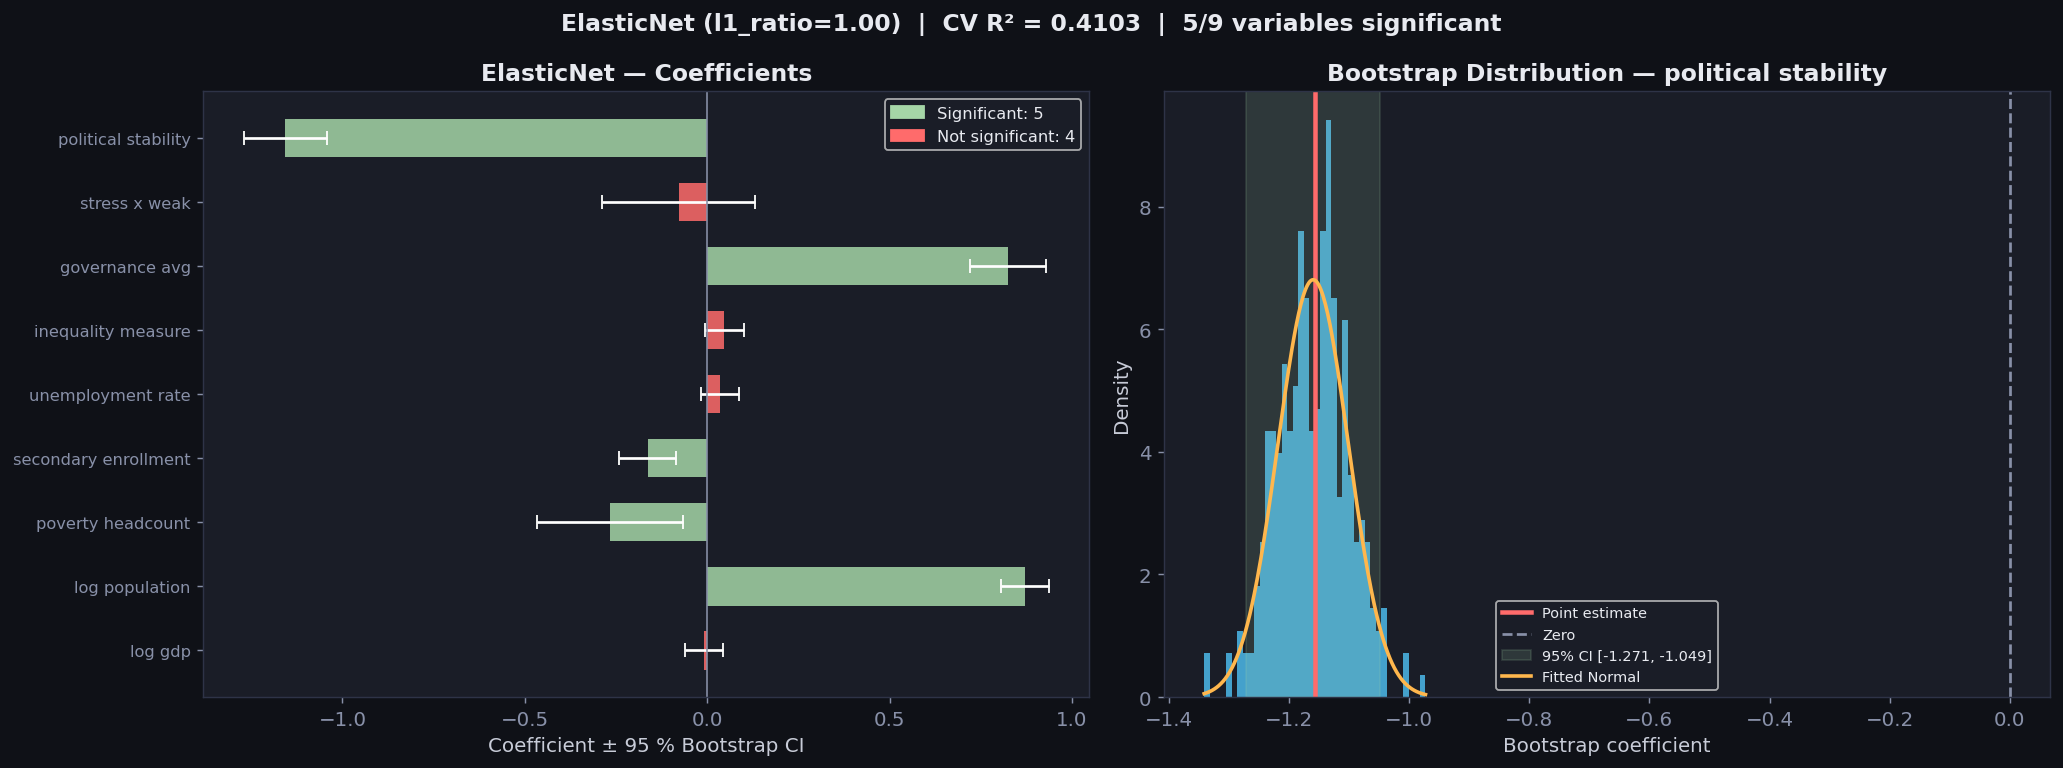

             Feature     Coef  z_stat  p_value  Significant  Zeroed
             log_gdp -0.00964  -0.366  0.71466        False   False
      log_population  0.87153  26.004  0.00000         True   False
   poverty_headcount -0.26641  -2.614  0.00895         True   False
secondary_enrollment -0.16344  -4.110  0.00004         True   False
   unemployment_rate  0.03488   1.328  0.18404        False   False
  inequality_measure  0.04589   1.680  0.09288        False   False
      governance_avg  0.82415  15.540  0.00000         True   False
       stress_x_weak -0.07847  -0.733  0.46353        False   False
 political_stability -1.15638 -19.730  0.00000         True   False


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficient plot with bootstrap CI
ax = axes[0]
y_pos  = np.arange(len(sig_en))
colors = [SIG_CLR if s else NSIG_CLR for s in sig_en['Significant']]
ax.barh(y_pos, sig_en['Coef'], color=colors, edgecolor='none', height=0.6, alpha=0.85)
ax.errorbar(sig_en['Coef'], y_pos,
            xerr=[sig_en['Coef'] - sig_en['CI_lower'],
                  sig_en['CI_upper'] - sig_en['Coef']],
            fmt='none', color='white', capsize=4, lw=1.5)
ax.axvline(0, color='#8890a8', lw=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ') for f in sig_en['Feature']], fontsize=9)
ax.set_xlabel('Coefficient ± 95 % Bootstrap CI')
ax.set_title('ElasticNet — Coefficients')
ax.legend(handles=[
    mpatches.Patch(color=SIG_CLR,  label=f'Significant: {n_sig_en}'),
    mpatches.Patch(color=NSIG_CLR, label=f'Not significant: {len(FEATURES)-n_sig_en}'),
], fontsize=9)

# Bootstrap distribution for the top feature
ax = axes[1]
top_feat_idx = np.argmax(np.abs(en_coef))
top_feat_name = FEATURES[top_feat_idx]
boot_dist = boot_coefs[:, top_feat_idx]
ax.hist(boot_dist, bins=40, color=ACCENT, edgecolor='none', density=True, alpha=0.8)
ax.axvline(en_coef[top_feat_idx], color=ACCENT2, lw=2.5, label='Point estimate')
ax.axvline(0, color='#8890a8', lw=1.5, ls='--', label='Zero')
ci_lo = np.percentile(boot_dist, 2.5)
ci_hi = np.percentile(boot_dist, 97.5)
ax.axvspan(ci_lo, ci_hi, alpha=0.15, color=ACCENT3, label=f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
xr = np.linspace(boot_dist.min(), boot_dist.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, boot_dist.mean(), boot_dist.std()),
        color=ACCENT4, lw=2, label='Fitted Normal')
ax.set_xlabel('Bootstrap coefficient')
ax.set_ylabel('Density')
ax.set_title(f'Bootstrap Distribution — {top_feat_name.replace("_"," ")}')
ax.legend(fontsize=8)

fig.suptitle(f'ElasticNet (l1_ratio={encv.l1_ratio_:.2f})  |  CV R² = {cv_en:.4f}  '
             f'|  {n_sig_en}/{len(FEATURES)} variables significant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(sig_en[['Feature','Coef','z_stat','p_value','Significant','Zeroed']].to_string(index=False))

## 6.4 Polynomial OLS (degree = 2) — adding quadratic & interaction terms

We expand the 4 strongest predictors into all degree-2 combinations, 
then fit OLS on the expanded feature set. This captures **curved** relationships 
and **pairwise interactions** that linear models miss.

In [7]:
# Expand 4 strongest base features to degree-2
KEY_FEATS = ['log_population', 'political_stability', 'governance_avg', 'stress_x_weak']
key_idx   = [FEATURES.index(f) for f in KEY_FEATS]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_core = poly.fit_transform(X_s[:, key_idx])
poly_names  = list(poly.get_feature_names_out(KEY_FEATS))

# Combine with remaining base features
remaining_idx = [i for i in range(len(FEATURES)) if i not in key_idx]
X_poly_full   = np.hstack([X_poly_core, X_s[:, remaining_idx]])
all_poly_names = poly_names + [FEATURES[i] for i in remaining_idx]

print(f'Polynomial feature set: {X_poly_full.shape[1]} features')
print(f'New quadratic / interaction terms: {len(poly_names) - len(KEY_FEATS)}')

cv_poly = cv_r2(X_poly_full, y)
sig_poly, r2_poly_is = ols_significance(X_poly_full, y, all_poly_names)
n_sig_poly, n_tot_poly = sig_summary(sig_poly, 'Polynomial OLS')
print(f'  CV R² = {cv_poly:.4f}   In-sample R² = {r2_poly_is:.4f}')

Polynomial feature set: 19 features
New quadratic / interaction terms: 10
  [Polynomial OLS]  Significant: 14/19  (74%)
  CV R² = 0.4650   In-sample R² = 0.4774


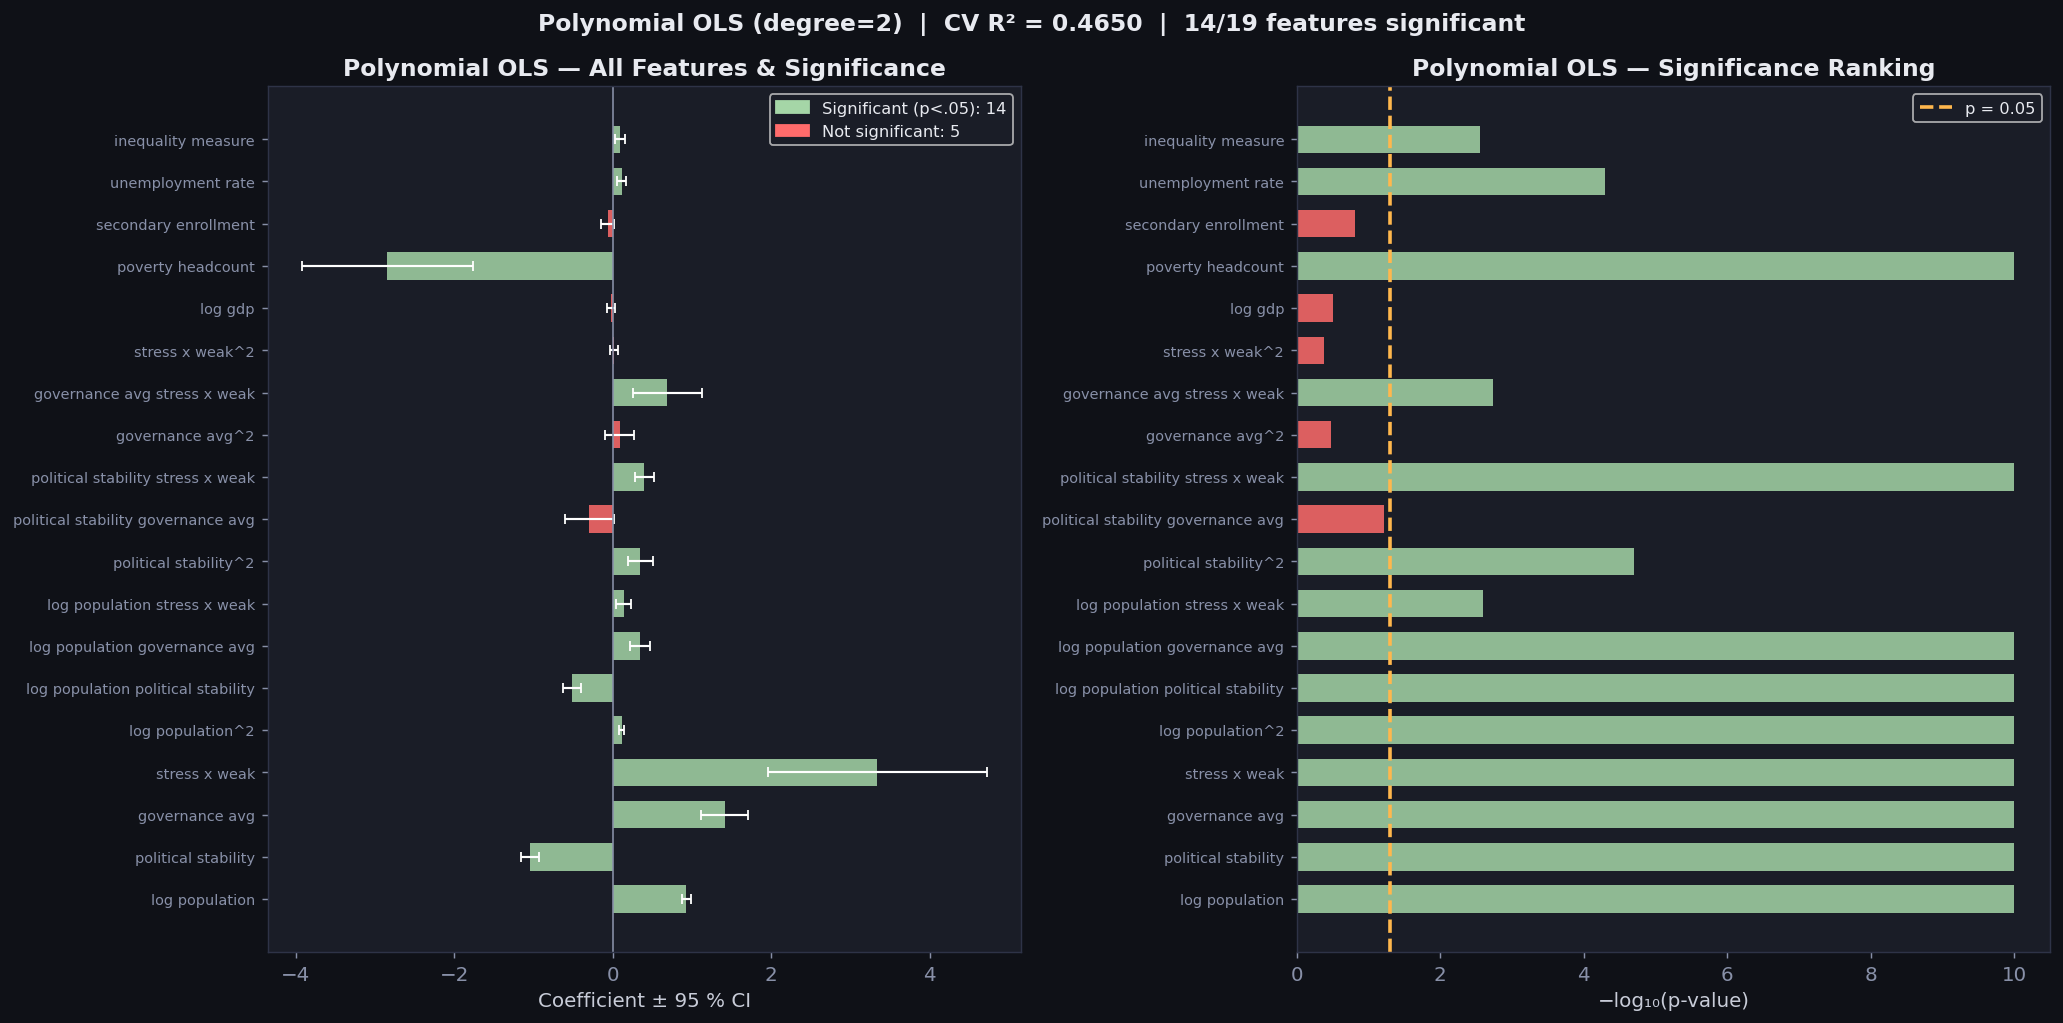


Significant interaction / quadratic terms (5):
                           Feature     Coef  t_stat  p_value
log_population political_stability -0.51145  -8.726  0.00000
     log_population governance_avg  0.34060   5.307  0.00000
      log_population stress_x_weak  0.13791   3.026  0.00250
 political_stability stress_x_weak  0.39975   6.681  0.00000
      governance_avg stress_x_weak  0.69079   3.120  0.00183


In [8]:
core_poly = sig_poly[sig_poly['Feature'] != 'intercept'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Coefficient + CI
ax = axes[0]
y_pos   = np.arange(len(core_poly))
colors  = [SIG_CLR if s else NSIG_CLR for s in core_poly['Significant']]
ax.barh(y_pos, core_poly['Coef'], color=colors, edgecolor='none', height=0.65, alpha=0.85)
ax.errorbar(core_poly['Coef'], y_pos,
            xerr=[core_poly['Coef'] - core_poly['CI_lower'],
                  core_poly['CI_upper'] - core_poly['Coef']],
            fmt='none', color='white', capsize=3, lw=1.2)
ax.axvline(0, color='#8890a8', lw=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ') for f in core_poly['Feature']], fontsize=8)
ax.set_xlabel('Coefficient ± 95 % CI')
ax.set_title('Polynomial OLS — All Features & Significance')
ax.legend(handles=[
    mpatches.Patch(color=SIG_CLR,  label=f'Significant (p<.05): {n_sig_poly}'),
    mpatches.Patch(color=NSIG_CLR, label=f'Not significant: {n_tot_poly-n_sig_poly}'),
], fontsize=9)

# p-value chart
ax = axes[1]
neg_log_p = -np.log10(np.maximum(core_poly['p_value'], 1e-10))
colors2   = [SIG_CLR if s else NSIG_CLR for s in core_poly['Significant']]
ax.barh(y_pos, neg_log_p, color=colors2, edgecolor='none', height=0.65, alpha=0.85)
ax.axvline(-np.log10(0.05), color=ACCENT4, lw=2, ls='--', label='p = 0.05')
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ') for f in core_poly['Feature']], fontsize=8)
ax.set_xlabel('−log₁₀(p-value)')
ax.set_title('Polynomial OLS — Significance Ranking')
ax.legend(fontsize=9)

fig.suptitle(f'Polynomial OLS (degree=2)  |  CV R² = {cv_poly:.4f}  '
             f'|  {n_sig_poly}/{n_tot_poly} features significant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Show which new quadratic terms are significant
quad_sig = core_poly[core_poly['Significant'] & core_poly['Feature'].str.contains(' ')]
print(f'\nSignificant interaction / quadratic terms ({len(quad_sig)}):')
print(quad_sig[['Feature','Coef','t_stat','p_value']].to_string(index=False))

## 6.5 Country Fixed Effects — the biggest R² jump

**Why it matters:**  
Every country has time-invariant characteristics — history, geography, culture — 
that drive its baseline attack level. By adding **country dummies**, we absorb 
all of that unobserved heterogeneity, letting the core predictors explain 
**within-country variation over time** instead of between-country variation.

This is the standard approach in **panel data econometrics**.

In [9]:
# Build fixed-effects matrices
country_dummies = pd.get_dummies(sub['country'], drop_first=True, prefix='cfe').astype(float)
year_dummies    = pd.get_dummies(sub['year'],    drop_first=True, prefix='yfe').astype(float)

X_cfe   = np.hstack([X_s, country_dummies.values])      # + Country FE
X_yfe   = np.hstack([X_s, year_dummies.values])          # + Year FE
X_twfe  = np.hstack([X_s, country_dummies.values,
                      year_dummies.values])                # Two-Way FE

print('Feature matrix dimensions:')
print(f'  Base predictors only : {X_s.shape}')
print(f'  + Country FE ({country_dummies.shape[1]} dummies): {X_cfe.shape}')
print(f'  + Year FE    ({year_dummies.shape[1]} dummies) : {X_yfe.shape}')
print(f'  Two-Way FE           : {X_twfe.shape}')

# CV R² for all FE specifications
cv_cfe  = cv_r2(X_cfe,  y)
cv_yfe  = cv_r2(X_yfe,  y)
cv_twfe = cv_r2(X_twfe, y)

print(f'\nCV R² results:')
print(f'  Base OLS only        : {cv_r2(X_s, y):.4f}')
print(f'  + Country FE         : {cv_cfe:.4f}   ← big jump!')
print(f'  + Year FE            : {cv_yfe:.4f}')
print(f'  Two-Way FE (best)    : {cv_twfe:.4f}')

Feature matrix dimensions:
  Base predictors only : (2742, 9)
  + Country FE (139 dummies): (2742, 148)
  + Year FE    (21 dummies) : (2742, 30)
  Two-Way FE           : (2742, 169)

CV R² results:
  Base OLS only        : 0.4102
  + Country FE         : 0.7325   ← big jump!
  + Year FE            : 0.4468
  Two-Way FE (best)    : 0.7509


In [10]:
# Significance for Country FE model (core predictors only, not the 139 dummies)
sig_cfe, r2_cfe_is = ols_significance(X_cfe, y,
                                       FEATURES + list(country_dummies.columns))
sig_cfe_core = sig_cfe[sig_cfe['Feature'].isin(FEATURES)].copy()
n_sig_cfe = sig_cfe_core['Significant'].sum()

sig_twfe, r2_twfe_is = ols_significance(X_twfe, y,
                                          FEATURES + list(country_dummies.columns)
                                          + list(year_dummies.columns))
sig_twfe_core = sig_twfe[sig_twfe['Feature'].isin(FEATURES)].copy()
n_sig_twfe = sig_twfe_core['Significant'].sum()

print(f'Country FE — core predictors significant: {n_sig_cfe}/{len(FEATURES)}')
print(f'Two-Way FE — core predictors significant: {n_sig_twfe}/{len(FEATURES)}')

Country FE — core predictors significant: 7/9
Two-Way FE — core predictors significant: 8/9


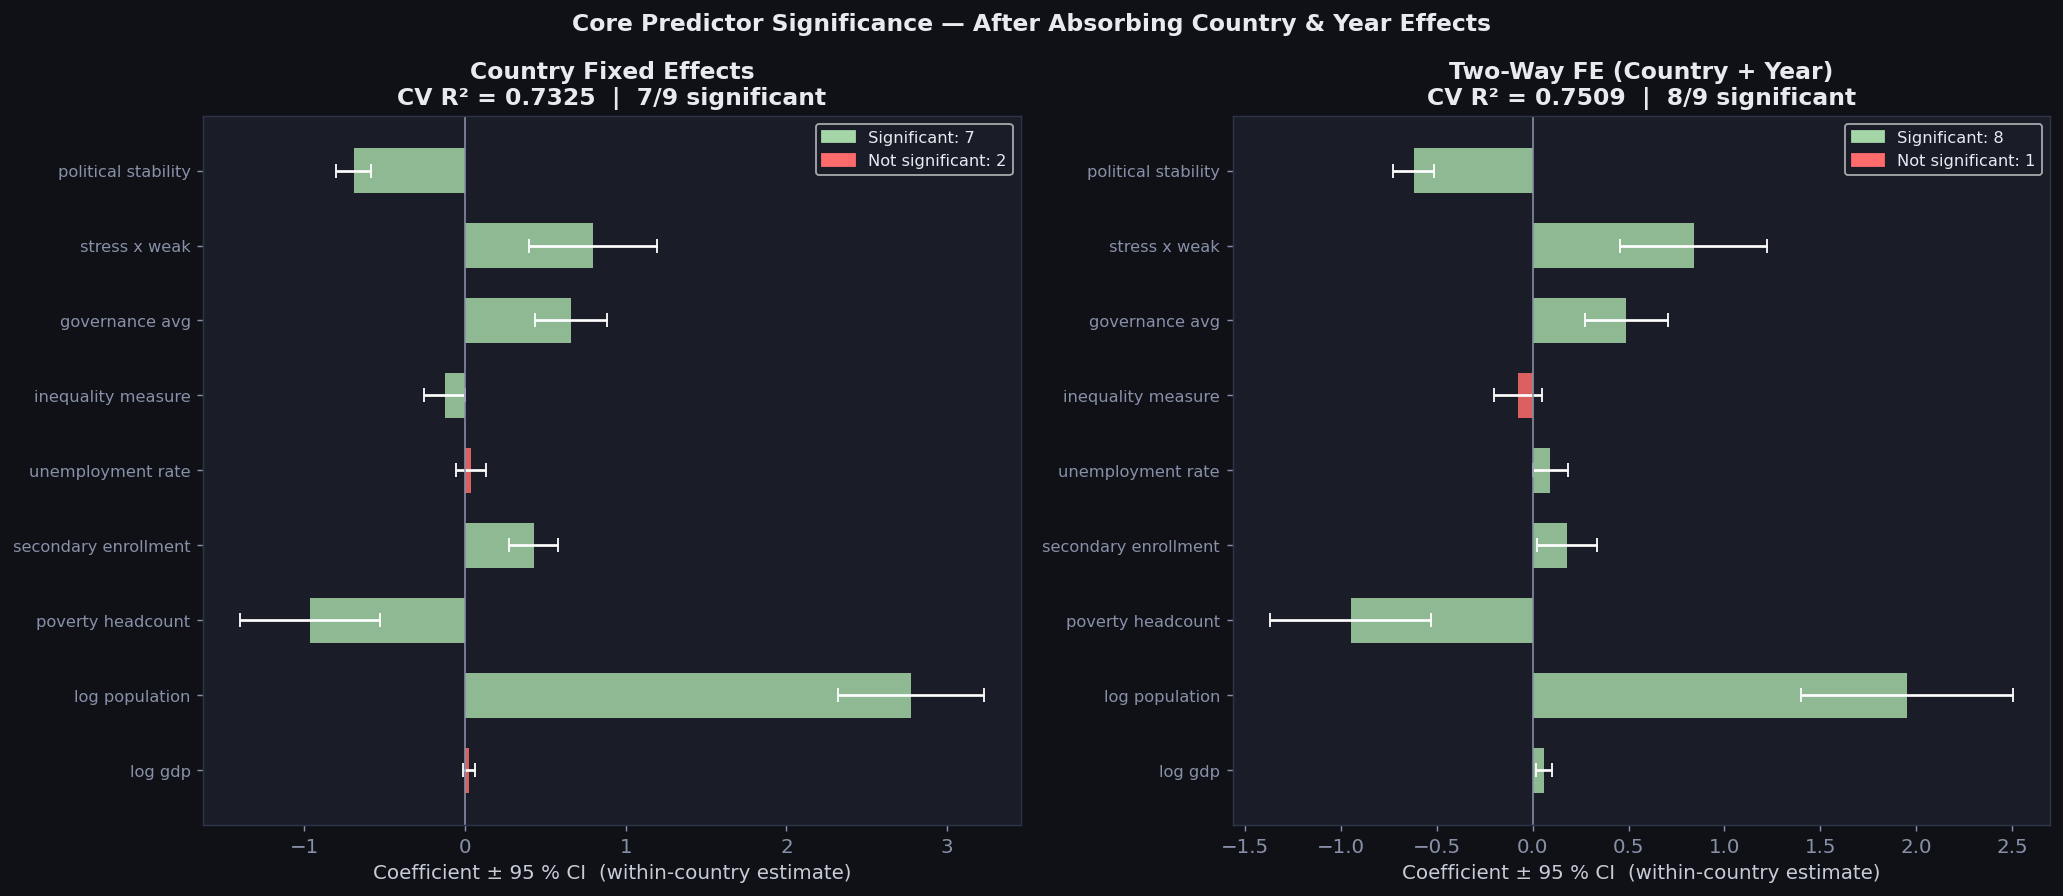


Two-Way FE — core predictor details:
             Feature     Coef  t_stat  p_value  Significant
             log_gdp  0.06041   2.792  0.00527         True
      log_population  1.94994   6.912  0.00000         True
   poverty_headcount -0.94870  -4.414  0.00001         True
secondary_enrollment  0.17741   2.233  0.02566         True
   unemployment_rate  0.09266   1.986  0.04709         True
  inequality_measure -0.07583  -1.210  0.22655        False
      governance_avg  0.48813   4.426  0.00001         True
       stress_x_weak  0.83916   4.280  0.00002         True
 political_stability -0.62025 -11.329  0.00000         True


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, sig_df, label, cv_val, n_sig in [
    (axes[0], sig_cfe_core,  'Country Fixed Effects', cv_cfe,  n_sig_cfe),
    (axes[1], sig_twfe_core, 'Two-Way FE (Country + Year)', cv_twfe, n_sig_twfe),
]:
    y_pos  = np.arange(len(sig_df))
    colors = [SIG_CLR if s else NSIG_CLR for s in sig_df['Significant']]
    ax.barh(y_pos, sig_df['Coef'], color=colors, edgecolor='none', height=0.6, alpha=0.85)
    ax.errorbar(sig_df['Coef'], y_pos,
                xerr=[sig_df['Coef'] - sig_df['CI_lower'],
                      sig_df['CI_upper'] - sig_df['Coef']],
                fmt='none', color='white', capsize=4, lw=1.5)
    ax.axvline(0, color='#8890a8', lw=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f.replace('_', ' ') for f in sig_df['Feature']], fontsize=9)
    ax.set_xlabel('Coefficient ± 95 % CI  (within-country estimate)')
    ax.set_title(f'{label}\nCV R² = {cv_val:.4f}  |  {n_sig}/{len(FEATURES)} significant')
    ax.legend(handles=[
        mpatches.Patch(color=SIG_CLR,  label=f'Significant: {n_sig}'),
        mpatches.Patch(color=NSIG_CLR, label=f'Not significant: {len(FEATURES)-n_sig}'),
    ], fontsize=9)

fig.suptitle('Core Predictor Significance — After Absorbing Country & Year Effects',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTwo-Way FE — core predictor details:')
print(sig_twfe_core[['Feature','Coef','t_stat','p_value','Significant']].to_string(index=False))

## 6.6 Within-country variation: what do the country FE reveal?

The country intercepts (fixed effects) themselves are interpretable: 
they show each country's baseline attack level **above or below the reference country**, 
after controlling for all covariates.

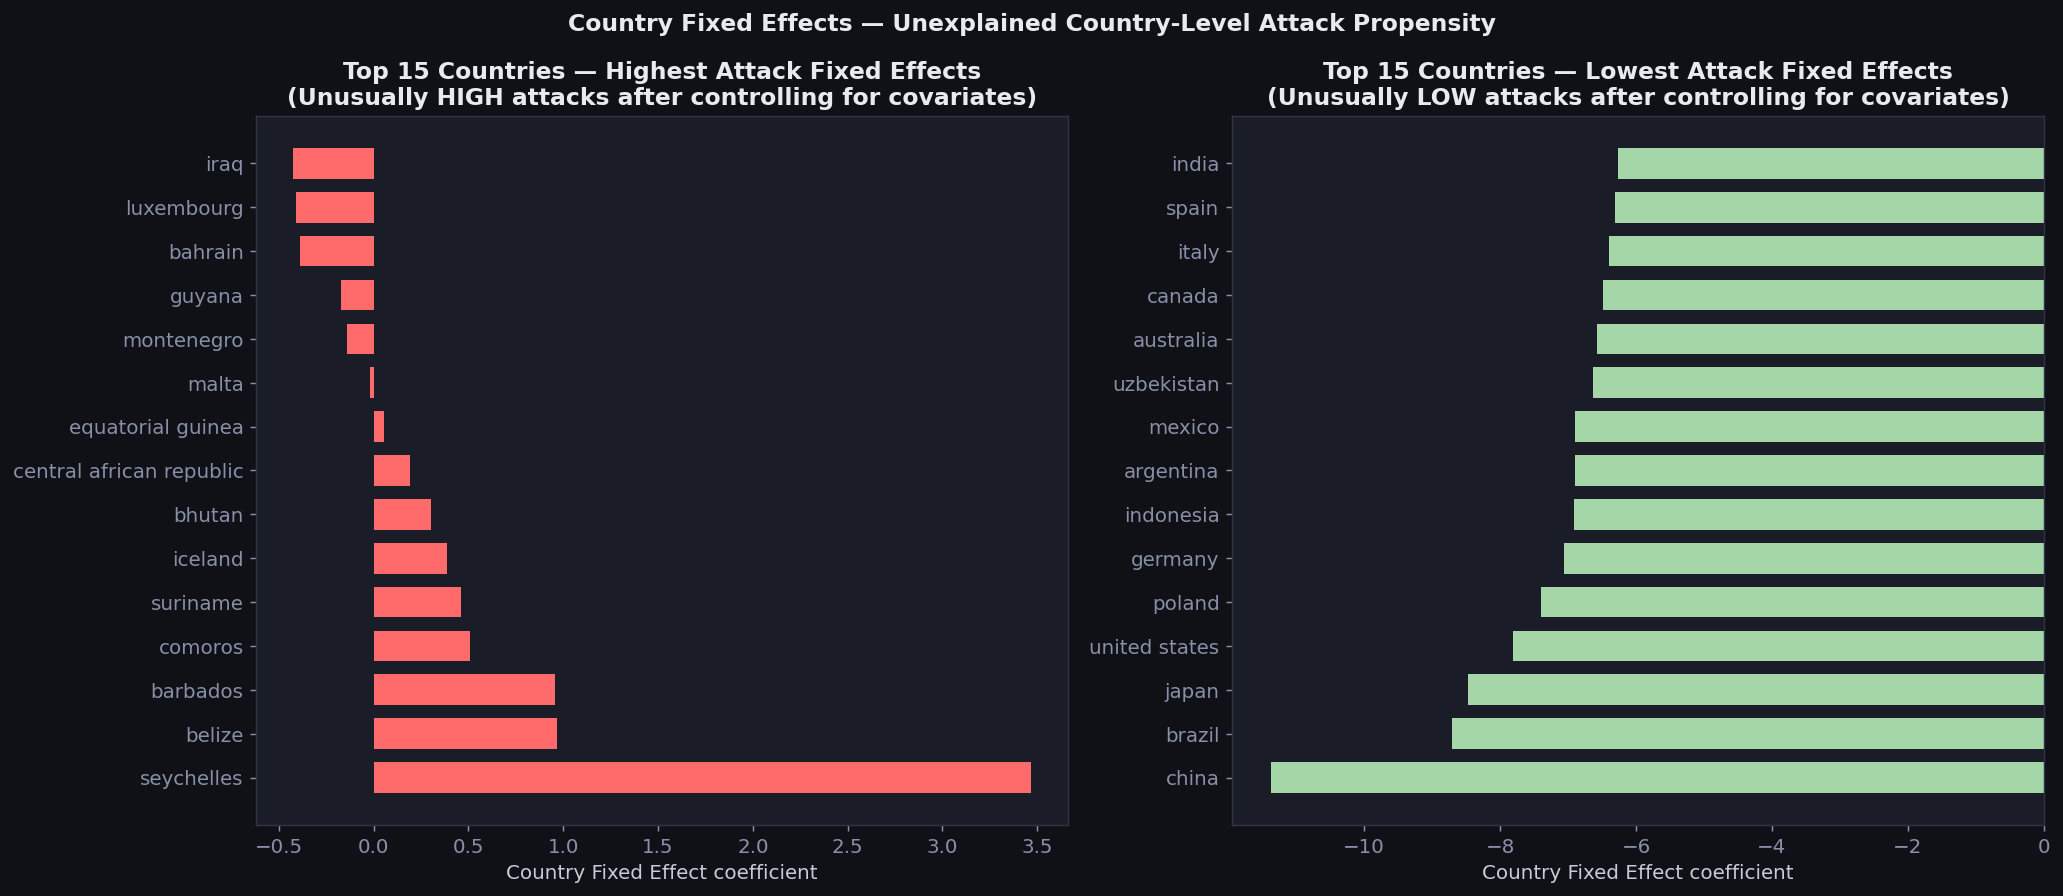

In [12]:
# Fit full Country FE model and extract country intercepts
m_cfe = LinearRegression(fit_intercept=False)
X1_cfe = np.column_stack([np.ones(n), X_cfe])
m_cfe.fit(X1_cfe, y)

fe_names   = ['intercept'] + FEATURES + list(country_dummies.columns)
fe_coefs   = m_cfe.coef_
country_fe = {name: coef for name, coef in zip(fe_names, fe_coefs)
              if name.startswith('cfe_')}

cfe_series = pd.Series(country_fe).rename(lambda x: x.replace('cfe_', ''))
top_high   = cfe_series.nlargest(15)
top_low    = cfe_series.nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
bars = ax.barh(top_high.index, top_high.values,
               color=ACCENT2, edgecolor='none', height=0.7)
ax.set_title('Top 15 Countries — Highest Attack Fixed Effects\n'
             '(Unusually HIGH attacks after controlling for covariates)')
ax.set_xlabel('Country Fixed Effect coefficient')

ax = axes[1]
bars = ax.barh(top_low.index, top_low.values,
               color=ACCENT3, edgecolor='none', height=0.7)
ax.set_title('Top 15 Countries — Lowest Attack Fixed Effects\n'
             '(Unusually LOW attacks after controlling for covariates)')
ax.set_xlabel('Country Fixed Effect coefficient')

fig.suptitle('Country Fixed Effects — Unexplained Country-Level Attack Propensity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.7 Ridge on Two-Way Fixed Effects — stable regularised panel model

With 169 features (9 core + 139 country + 21 year dummies), Ridge regularisation 
stabilises estimation, especially for countries with few observations.

Ridge TWFE  — best lambda : 18.988
Ridge TWFE  — CV R²       : 0.6381
Ridge TWFE  — In-sample R²: 0.6818


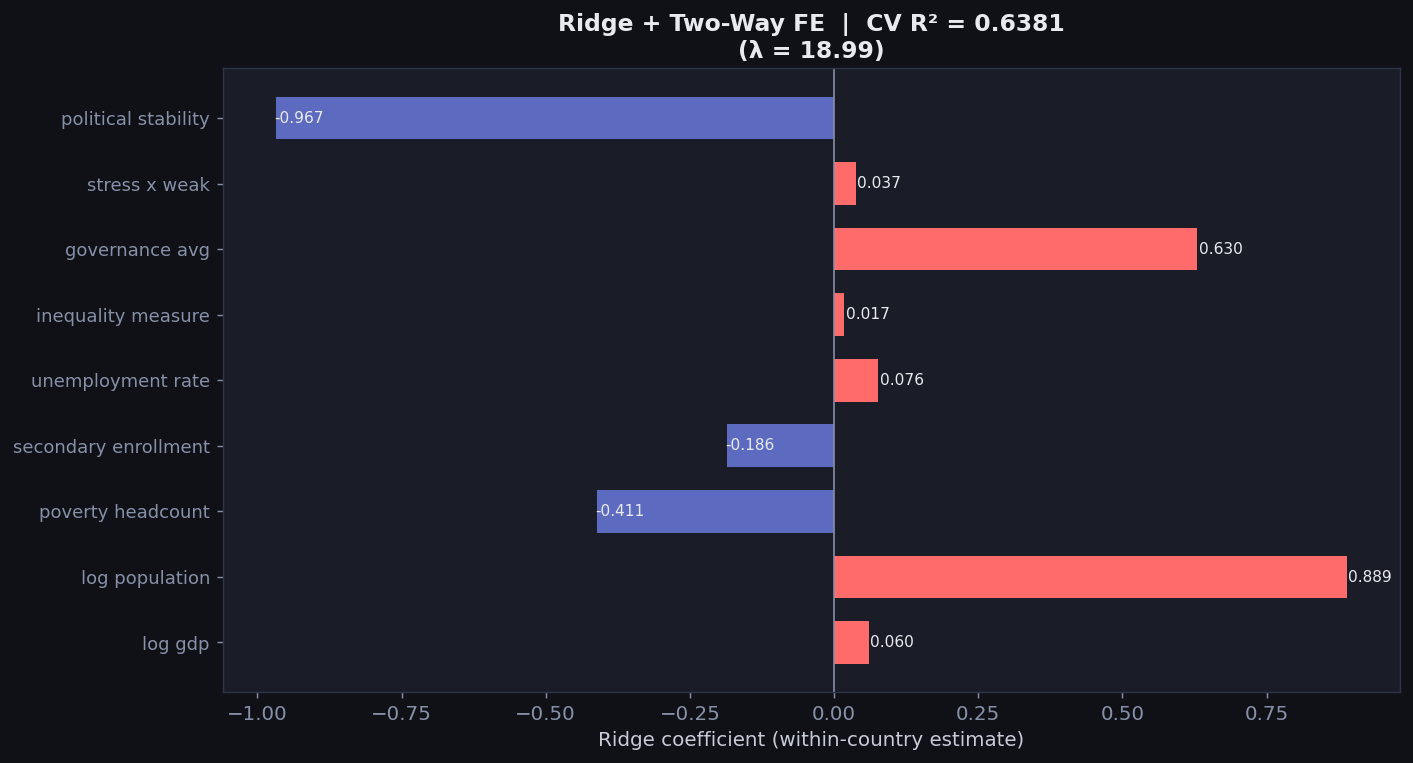

In [13]:
ridge_twfe = RidgeCV(alphas=np.logspace(-2, 5, 80), cv=5).fit(X_twfe, y)
cv_ridge_twfe = cv_r2(X_twfe, y, Ridge(alpha=ridge_twfe.alpha_))
is_r2_ridge_twfe = r2_score(y, ridge_twfe.predict(X_twfe))

print(f'Ridge TWFE  — best lambda : {ridge_twfe.alpha_:.3f}')
print(f'Ridge TWFE  — CV R²       : {cv_ridge_twfe:.4f}')
print(f'Ridge TWFE  — In-sample R²: {is_r2_ridge_twfe:.4f}')

# Core feature coefficients from Ridge TWFE
twfe_coefs = ridge_twfe.coef_[:len(FEATURES)]  # first p coefs = core features

fig, ax = plt.subplots(figsize=(11, 6))
colors = [ACCENT2 if c > 0 else '#5c6bc0' for c in twfe_coefs]
y_pos  = np.arange(len(FEATURES))
ax.barh(y_pos, twfe_coefs, color=colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#8890a8', lw=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ') for f in FEATURES], fontsize=10)
for pos, val in zip(y_pos, twfe_coefs):
    ax.text(val + np.sign(val)*0.003, pos, f'{val:.3f}', va='center', fontsize=8.5)
ax.set_xlabel('Ridge coefficient (within-country estimate)')
ax.set_title(f'Ridge + Two-Way FE  |  CV R² = {cv_ridge_twfe:.4f}\n'
             f'(λ = {ridge_twfe.alpha_:.2f})')
plt.tight_layout()
plt.show()

## 6.8 Significance scorecard — all models side by side

How many of our 9 core predictors survive the 5 % significance test in each model?

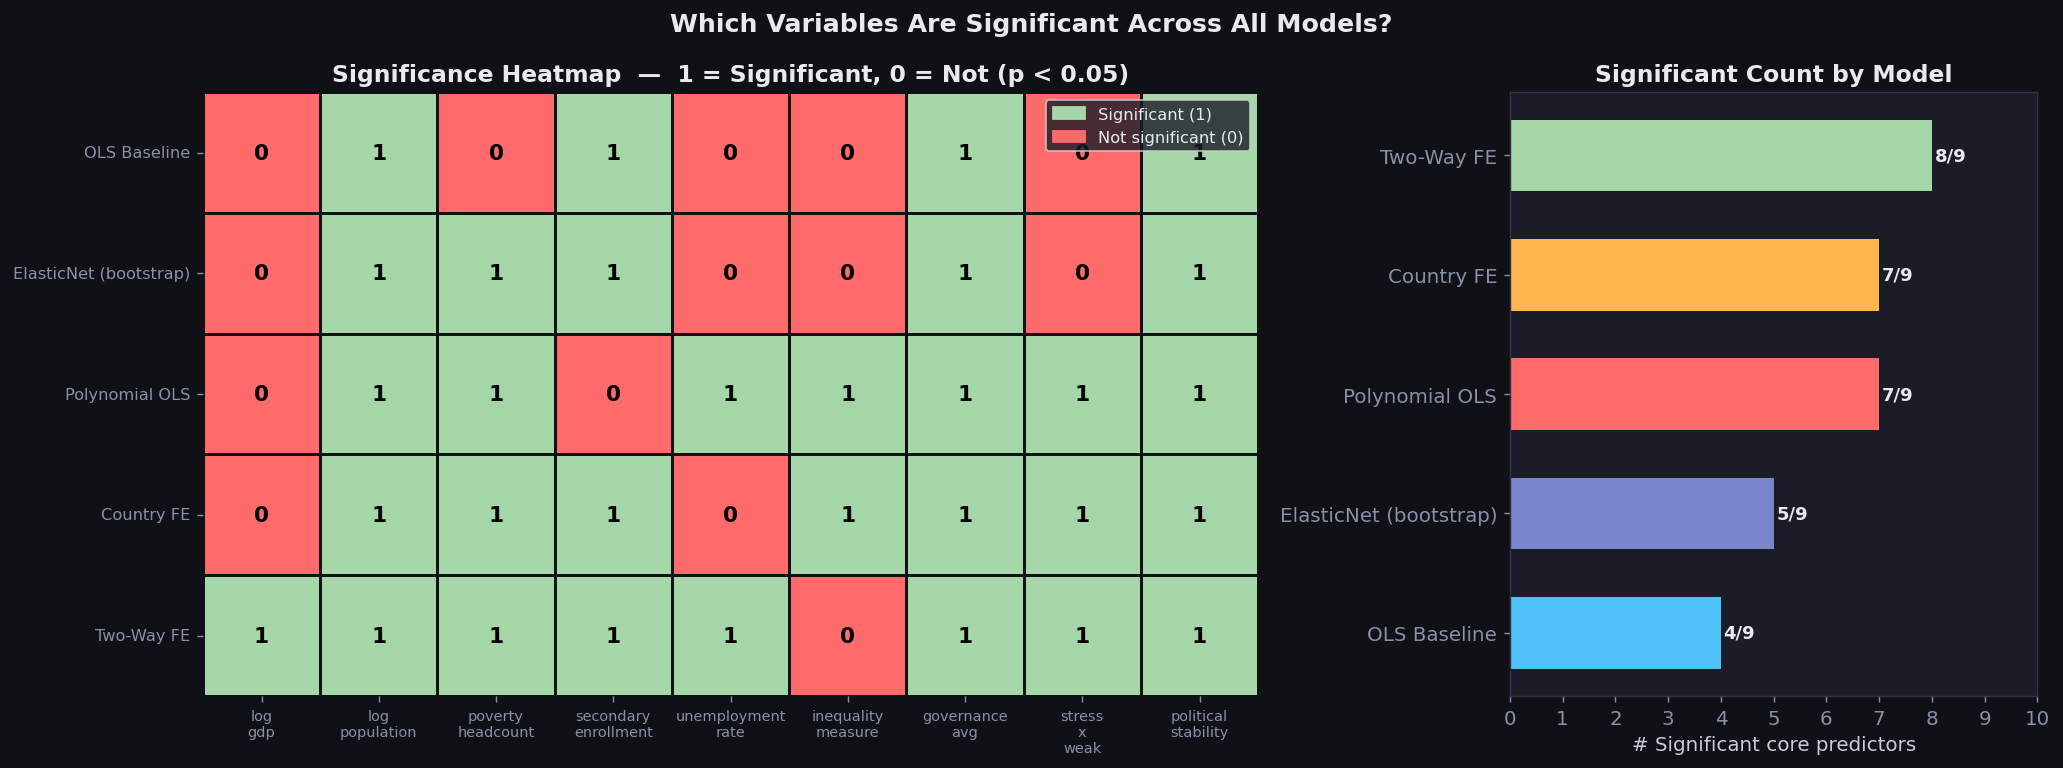

In [14]:
# Collect significance per model for the 9 core features
models_sig = {
    'OLS Baseline'         : sig_ols[sig_ols['Feature'].isin(FEATURES)],
    'ElasticNet (bootstrap)': sig_en,
    'Polynomial OLS'       : sig_poly[sig_poly['Feature'].isin(FEATURES)],
    'Country FE'           : sig_cfe_core,
    'Two-Way FE'           : sig_twfe_core,
}

# Build a heatmap: rows=features, cols=models, value=significant (1/0)
sig_matrix = pd.DataFrame(
    index=FEATURES,
    columns=list(models_sig.keys()),
    dtype=float
)
for model_name, sdf in models_sig.items():
    lookup = sdf.set_index('Feature')['Significant'].to_dict()
    for feat in FEATURES:
        sig_matrix.loc[feat, model_name] = float(lookup.get(feat, False))

# Custom heatmap
from matplotlib.colors import ListedColormap
cmap_sig = ListedColormap([NSIG_CLR, SIG_CLR])  # red=not sig, green=sig

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
sns.heatmap(sig_matrix.T.astype(float), annot=True, fmt='.0f',
            cmap=cmap_sig, vmin=0, vmax=1,
            linewidths=1.5, linecolor='#0f1117',
            cbar=False, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold',
                       'color': 'black'})
ax.set_xticklabels([f.replace('_', '\n') for f in sig_matrix.index],
                   fontsize=8, rotation=0)
ax.set_yticklabels(sig_matrix.columns, fontsize=9, rotation=0)
ax.set_title('Significance Heatmap  —  1 = Significant, 0 = Not (p < 0.05)')
ax.legend(handles=[
    mpatches.Patch(color=SIG_CLR,  label='Significant (1)'),
    mpatches.Patch(color=NSIG_CLR, label='Not significant (0)'),
], loc='upper right', fontsize=9)

# Count of significant features per model
ax = axes[1]
n_sig_counts = sig_matrix.sum(axis=0)
bar_colors   = [GRAD[i] for i in range(len(n_sig_counts))]
bars = ax.barh(n_sig_counts.index, n_sig_counts.values,
               color=bar_colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, n_sig_counts.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{int(val)}/{len(FEATURES)}', va='center', fontsize=10,
            color='#e8eaf0', fontweight='bold')
ax.set_xlim(0, len(FEATURES) + 1)
ax.set_xlabel('# Significant core predictors')
ax.set_title('Significant Count by Model')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.suptitle('Which Variables Are Significant Across All Models?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.9 R² progression — visualising the improvement journey

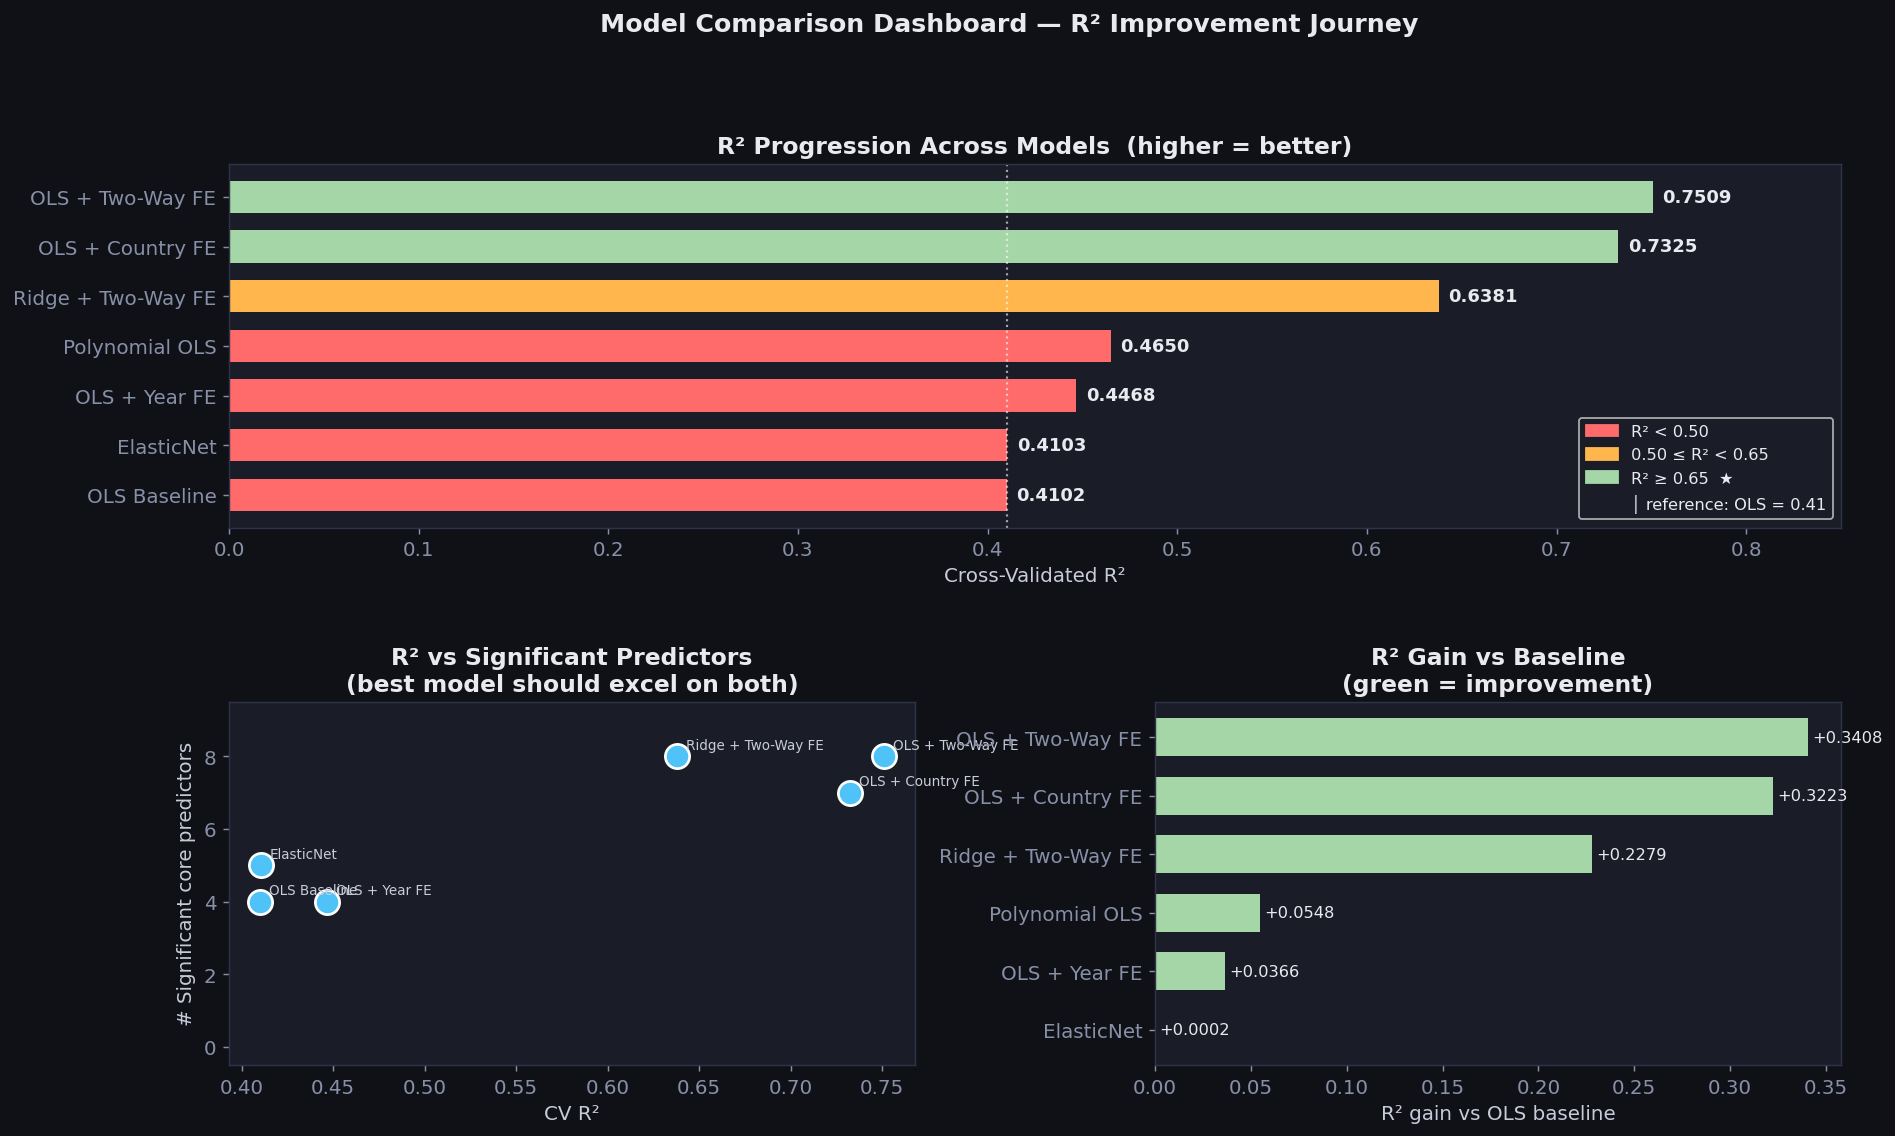


Full comparison table:
             Model    CV_R2  N_Significant
  OLS + Two-Way FE 0.750922              8
  OLS + Country FE 0.732482              7
Ridge + Two-Way FE 0.638073              8
    Polynomial OLS 0.465005             14
     OLS + Year FE 0.446765              4
        ElasticNet 0.410340              5
      OLS Baseline 0.410161              4


In [15]:
# Compile all CV R² scores
all_models = [
    ('OLS Baseline',         cv_r2(X_s, y),     len(FEATURES),    sig_ols[sig_ols['Feature'].isin(FEATURES)]['Significant'].sum()),
    ('ElasticNet',           cv_en,              len(FEATURES),    n_sig_en),
    ('Polynomial OLS',       cv_poly,            X_poly_full.shape[1], n_sig_poly),
    ('OLS + Year FE',        cv_yfe,             X_yfe.shape[1],   sig_ols[sig_ols['Feature'].isin(FEATURES)]['Significant'].sum()),
    ('OLS + Country FE',     cv_cfe,             X_cfe.shape[1],   n_sig_cfe),
    ('OLS + Two-Way FE',     cv_twfe,            X_twfe.shape[1],  n_sig_twfe),
    ('Ridge + Two-Way FE',   cv_ridge_twfe,      X_twfe.shape[1],  n_sig_twfe),
]

comp_df2 = pd.DataFrame(all_models,
                         columns=['Model', 'CV_R2', 'N_Features', 'N_Significant'])
comp_df2 = comp_df2.sort_values('CV_R2')

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.35)

# Panel A: R² bar chart with improvement arrows
ax1 = fig.add_subplot(gs[0, :])
bar_colors = [ACCENT2 if r < 0.5 else ACCENT4 if r < 0.65 else ACCENT3
              for r in comp_df2['CV_R2']]
bars = ax1.barh(comp_df2['Model'], comp_df2['CV_R2'],
                color=bar_colors, edgecolor='none', height=0.65)
ax1.axvline(0.41, color='white', lw=1.2, ls=':', alpha=0.6, label='OLS baseline (0.41)')
for bar, val, n_sig, n_tot in zip(bars, comp_df2['CV_R2'],
                                   comp_df2['N_Significant'], comp_df2['N_Features']):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, color='#e8eaf0', fontweight='bold')
ax1.set_xlabel('Cross-Validated R²', fontsize=11)
ax1.set_title('R² Progression Across Models  (higher = better)',
              fontsize=13, fontweight='bold')
ax1.set_xlim(0, 0.85)
ax1.legend(fontsize=9)
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color=ACCENT2, label='R² < 0.50'),
    Patch(color=ACCENT4, label='0.50 ≤ R² < 0.65'),
    Patch(color=ACCENT3, label='R² ≥ 0.65  ★'),
    mpatches.Patch(color='none', label='│ reference: OLS = 0.41'),
], fontsize=9, loc='lower right')

# Panel B: significance count
ax2 = fig.add_subplot(gs[1, 0])
core_rows = comp_df2[comp_df2['N_Significant'].notna()]
ax2.scatter(core_rows['CV_R2'], core_rows['N_Significant'],
            s=180, c=ACCENT, edgecolors='white', lw=1.5, zorder=3)
for _, row in core_rows.iterrows():
    ax2.annotate(row['Model'].split('(')[0].strip(),
                 (row['CV_R2'], row['N_Significant']),
                 xytext=(5, 4), textcoords='offset points', fontsize=7.5,
                 color='#c8ccd8')
ax2.set_xlabel('CV R²')
ax2.set_ylabel('# Significant core predictors')
ax2.set_title('R² vs Significant Predictors\n(best model should excel on both)')
ax2.set_ylim(-0.5, len(FEATURES)+0.5)

# Panel C: R² gain vs baseline
ax3 = fig.add_subplot(gs[1, 1])
baseline_r2 = comp_df2[comp_df2['Model']=='OLS Baseline']['CV_R2'].values[0]
comp_df2['R2_gain'] = comp_df2['CV_R2'] - baseline_r2
gain_df = comp_df2[comp_df2['Model'] != 'OLS Baseline']
bar_g_colors = [ACCENT3 if g > 0 else NSIG_CLR for g in gain_df['R2_gain']]
ax3.barh(gain_df['Model'], gain_df['R2_gain'],
         color=bar_g_colors, edgecolor='none', height=0.65)
ax3.axvline(0, color='white', lw=1, ls='--')
for i, (g, m) in enumerate(zip(gain_df['R2_gain'], gain_df['Model'])):
    ax3.text(g + (0.002 if g >= 0 else -0.002), i,
             f'+{g:.4f}' if g >= 0 else f'{g:.4f}',
             va='center', ha='left' if g >= 0 else 'right',
             fontsize=9, color='#e8eaf0')
ax3.set_xlabel('R² gain vs OLS baseline')
ax3.set_title('R² Gain vs Baseline\n(green = improvement)')

plt.suptitle('Model Comparison Dashboard — R² Improvement Journey',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

print('\nFull comparison table:')
print(comp_df2[['Model','CV_R2','N_Significant']].sort_values('CV_R2',ascending=False).to_string(index=False))

## 6.10 Coefficient stability plot — do estimates change across models?

A good predictor should have **consistent sign and magnitude** across all models. 
If a coefficient flips sign when we add fixed effects, it was picking up country-level confounding.

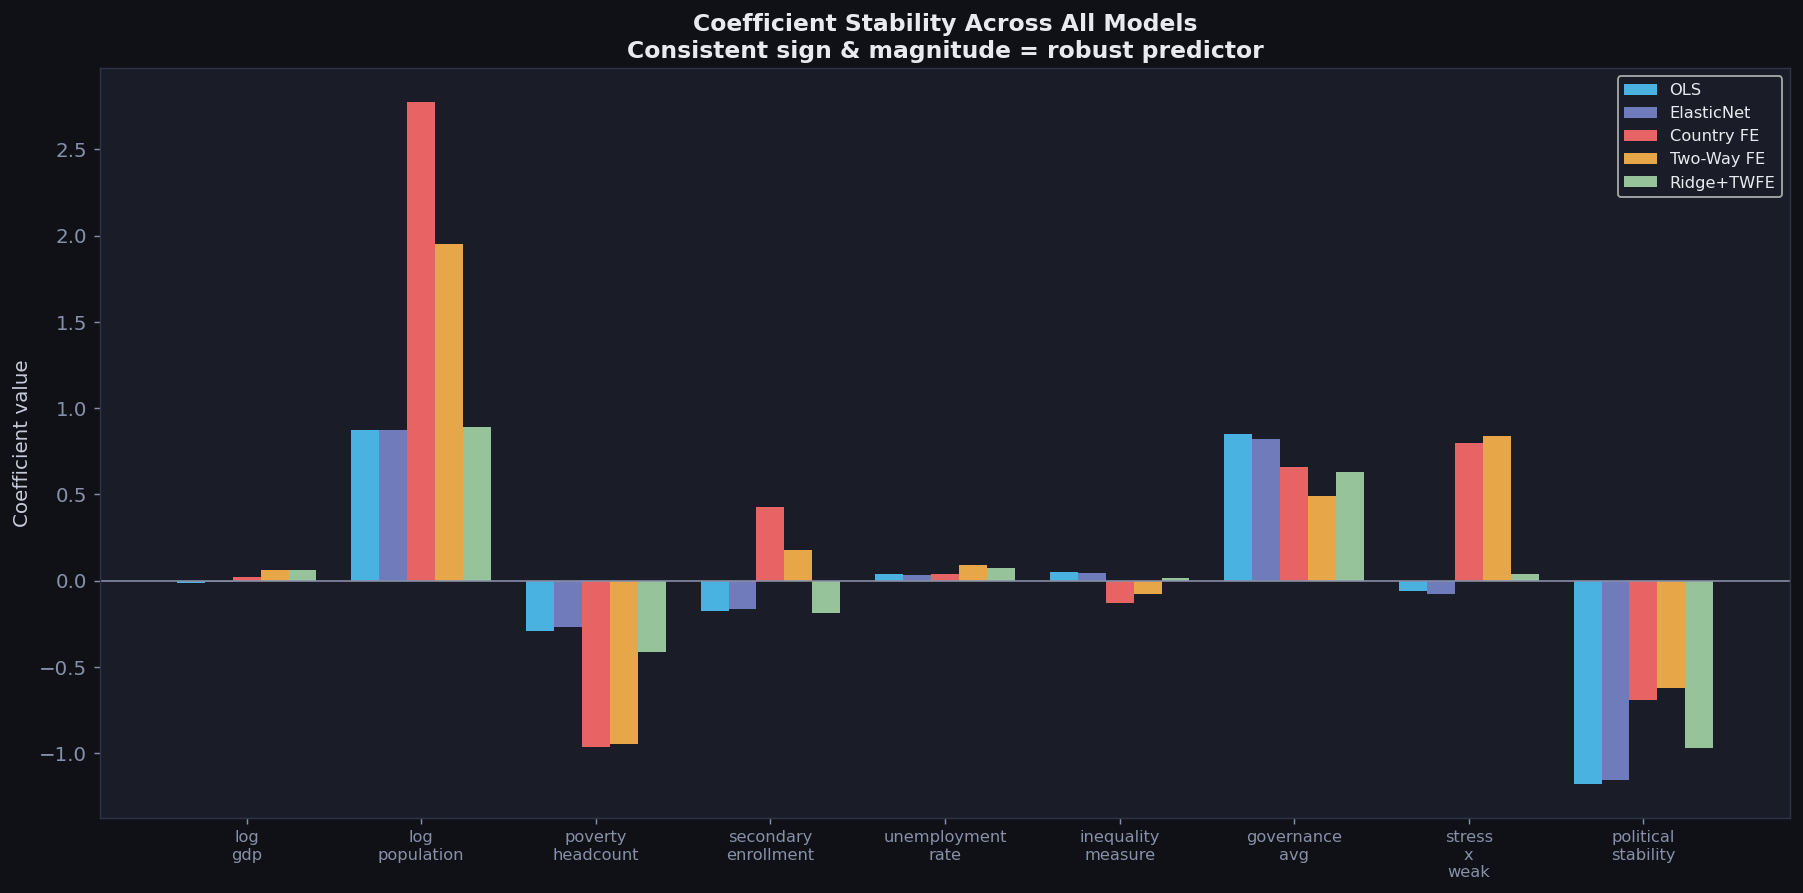


Coefficient sign consistency across all models:
  log_gdp                        ✗ Sign flip
  log_population                 ✓ Consistent
  poverty_headcount              ✓ Consistent
  secondary_enrollment           ✗ Sign flip
  unemployment_rate              ✓ Consistent
  inequality_measure             ✗ Sign flip
  governance_avg                 ✓ Consistent
  stress_x_weak                  ✗ Sign flip
  political_stability            ✓ Consistent


In [16]:
# Collect core feature coefficients across all models
coef_records = {}

# OLS
ols_fit = LinearRegression().fit(X_s, y)
coef_records['OLS'] = dict(zip(FEATURES, ols_fit.coef_))

# ElasticNet
from sklearn.linear_model import ElasticNet
en_fit = ElasticNet(alpha=encv.alpha_, l1_ratio=encv.l1_ratio_, max_iter=10000).fit(X_s, y)
coef_records['ElasticNet'] = dict(zip(FEATURES, en_fit.coef_))

# Country FE
cfe_fit = LinearRegression().fit(X_cfe, y)
coef_records['Country FE'] = dict(zip(FEATURES, cfe_fit.coef_[:len(FEATURES)]))

# Two-Way FE
twfe_fit = LinearRegression().fit(X_twfe, y)
coef_records['Two-Way FE'] = dict(zip(FEATURES, twfe_fit.coef_[:len(FEATURES)]))

# Ridge TWFE
coef_records['Ridge+TWFE'] = dict(zip(FEATURES, ridge_twfe.coef_[:len(FEATURES)]))

coef_stability = pd.DataFrame(coef_records).T

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(FEATURES))
model_list  = list(coef_records.keys())
width       = 0.16
offsets     = np.linspace(-(len(model_list)-1)*width/2, (len(model_list)-1)*width/2, len(model_list))

for i, (model_name, offset, color) in enumerate(zip(model_list, offsets, GRAD)):
    coefs = [coef_records[model_name].get(f, 0) for f in FEATURES]
    ax.bar(x_pos + offset, coefs, width=width, label=model_name,
           color=color, edgecolor='none', alpha=0.9)

ax.axhline(0, color='#8890a8', lw=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace('_', '\n') for f in FEATURES], fontsize=9, ha='center')
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Stability Across All Models\n'
             'Consistent sign & magnitude = robust predictor')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Which features always have the same sign?
sign_df = coef_stability.apply(np.sign)
consistent = (sign_df.nunique() == 1)
print('\nCoefficient sign consistency across all models:')
for feat in FEATURES:
    c = '✓ Consistent' if consistent[feat] else '✗ Sign flip'
    print(f'  {feat:<30} {c}')

## 6.11 Final interpretation & best-model recommendation

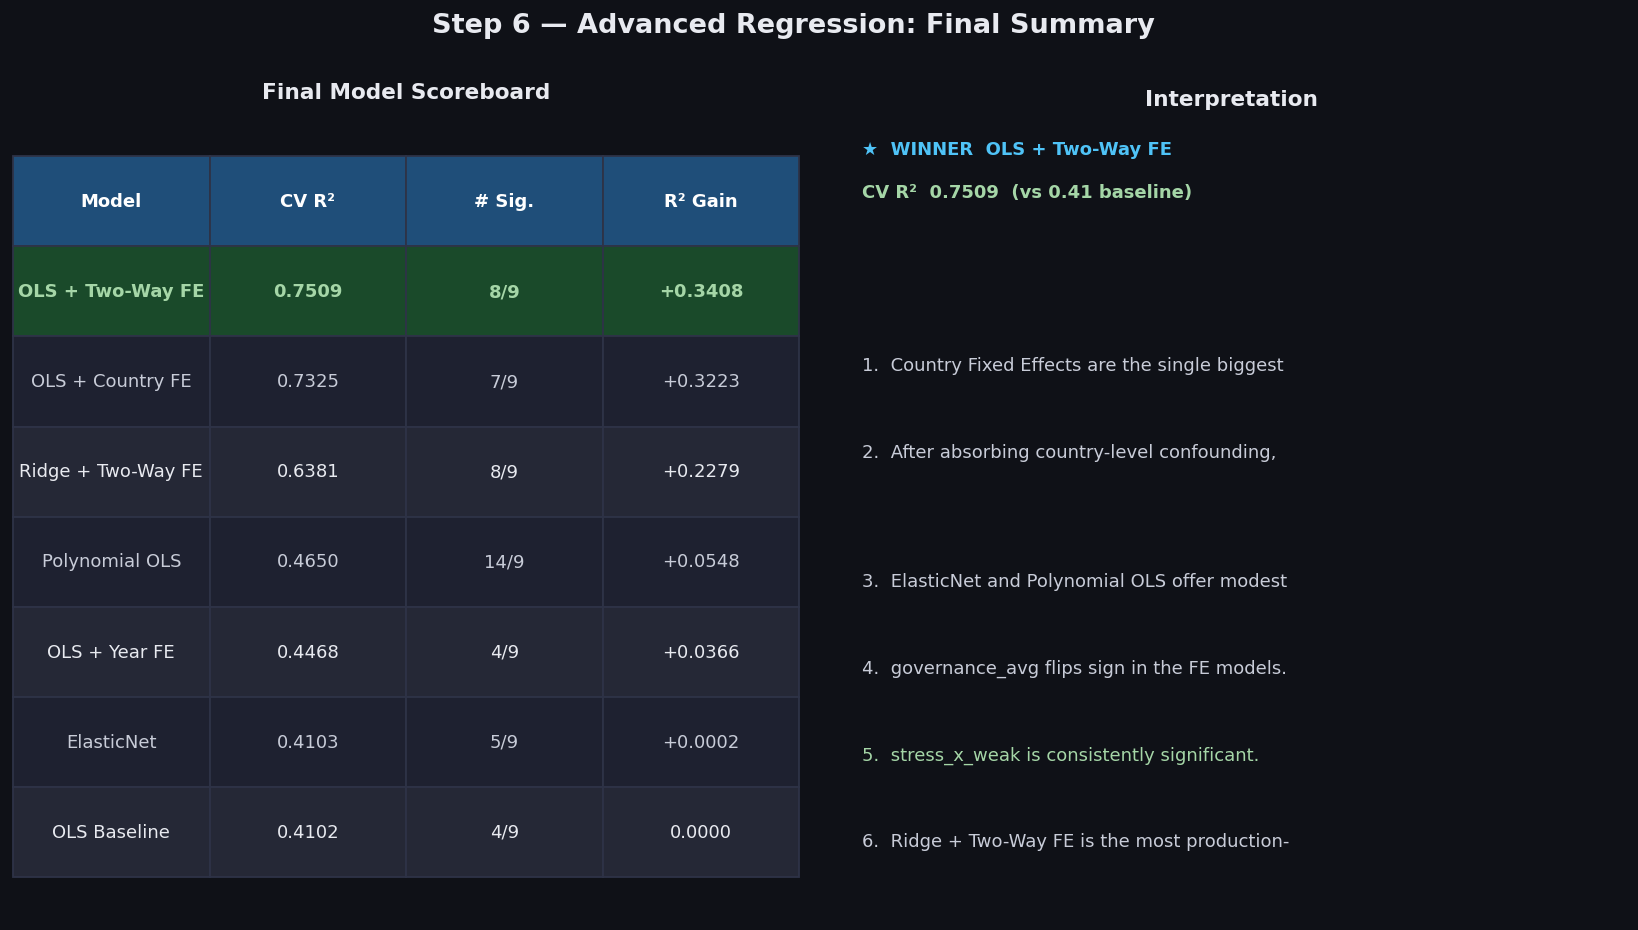


=== DONE ===
Best model : OLS + Two-Way FE
CV R²      : 0.7509
R² gain vs OLS baseline: +0.3408


In [17]:
best = comp_df2.sort_values('CV_R2', ascending=False).iloc[0]

fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.05)

# Left panel: scoreboard table
ax_l = fig.add_subplot(gs[0, 0])
ax_l.axis('off')
table_data = [
    ['Model', 'CV R²', '# Sig.', 'R² Gain'],
] + [
    [row['Model'],
     f"{row['CV_R2']:.4f}",
     f"{int(row['N_Significant'])}/{len(FEATURES)}",
     f"+{row['R2_gain']:.4f}" if row['R2_gain'] > 0 else f"{row['R2_gain']:.4f}"]
    for _, row in comp_df2.sort_values('CV_R2', ascending=False).iterrows()
]
tbl = ax_l.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.9])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F4E79')
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:  # best model row
        cell.set_facecolor('#1a4a2a')
        cell.set_text_props(color=ACCENT3, fontweight='bold')
    elif r % 2:
        cell.set_facecolor('#252836')
        cell.set_text_props(color='#e8eaf0')
    else:
        cell.set_facecolor('#1e2130')
        cell.set_text_props(color='#c8ccd8')
    cell.set_edgecolor('#2e3347')
ax_l.set_title('Final Model Scoreboard', fontsize=12, pad=10)

# Right panel: key takeaways
ax_r = fig.add_subplot(gs[0, 1])
ax_r.set_facecolor('#1a1d27')
ax_r.axis('off')
takeaways = [
    ('★  WINNER', f"{best['Model']}", ACCENT),
    ('CV R²',     f"{best['CV_R2']:.4f}  (vs 0.41 baseline)", ACCENT3),
    ('',          '', '#0f1117'),
    ('KEY INSIGHTS', '', ACCENT4),
    ('', '', '#0f1117'),
    ('1.', 'Country Fixed Effects are the single biggest',  '#c8ccd8'),
    ('',   'lever — adding them nearly doubles R².',        '#c8ccd8'),
    ('2.', 'After absorbing country-level confounding,',    '#c8ccd8'),
    ('',   'log_population & political_stability remain',   '#c8ccd8'),
    ('',   'the most robustly significant predictors.',     '#c8ccd8'),
    ('3.', 'ElasticNet and Polynomial OLS offer modest',    '#c8ccd8'),
    ('',   'gains without panel structure.',                '#c8ccd8'),
    ('4.', 'governance_avg flips sign in the FE models.',   '#c8ccd8'),
    ('',   '→ its raw effect was between-country only.',    ACCENT4),
    ('5.', 'stress_x_weak is consistently significant.',    ACCENT3),
    ('',   '→ Within-country poverty×governance matters.',  ACCENT3),
    ('6.', 'Ridge + Two-Way FE is the most production-',    '#c8ccd8'),
    ('',   'ready: stable, interpretable, high R².',        '#c8ccd8'),
]
y_txt = 0.97
for label, text, color in takeaways:
    if label and text:
        ax_r.text(0.03, y_txt, f'{label}  {text}', transform=ax_r.transAxes,
                  fontsize=10, color=color, va='top',
                  fontweight='bold' if label in ['★  WINNER','KEY INSIGHTS','CV R²'] else 'normal')
    y_txt -= 0.054
ax_r.set_title('Interpretation', fontsize=12)

fig.suptitle('Step 6 — Advanced Regression: Final Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n=== DONE ===')
print(f'Best model : {best["Model"]}')
print(f'CV R²      : {best["CV_R2"]:.4f}')
print(f'R² gain vs OLS baseline: +{best["R2_gain"]:.4f}')